In [1]:
%load_ext autoreload
%autoreload 2

import sys
from functools import partial
from matplotlib import pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import matplotlib as mpl
colors = plt.cm.plasma_r(np.linspace(0, 1, 6))[1:-1]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

from smbhb_jax import smbhb_two_masses, _period_observed

/home/phuijse/Work/PLATO_spikey/.venv/lib/python3.13/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/phuijse/.config', but the default location, /home/phuijse/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


# Reproducing Spikey

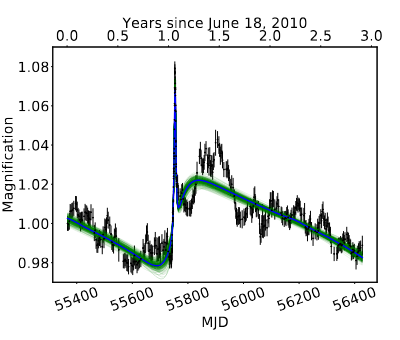

Text(0, 0.5, 'Magnification')

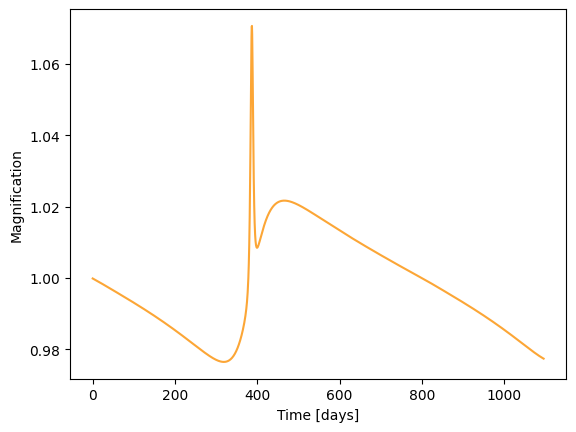

In [2]:
spikey_params = {
    'z': 0.918, 't0': 1.050, 'P': 1.144, 'i': jnp.rad2deg(jnp.arccos(0.140)), 'e': 0.524, 'w': jnp.rad2deg(1.477),
    'L': 0.89, 'alpha': 2.09, 'vz': 0.0, 'logM1': 7.4, 'logM2': 6.7,
}

time = jnp.linspace(0, 3*365.25, 2000)
smbhb_partial = partial(smbhb_two_masses, **spikey_params)

fig, ax = plt.subplots()
ax.plot(time, (jax.vmap(smbhb_partial))(time))
ax.set_xlabel('Time [days]')
ax.set_ylabel('Magnification')

# Reproducing Fig. 2 in Hu et al. 2020

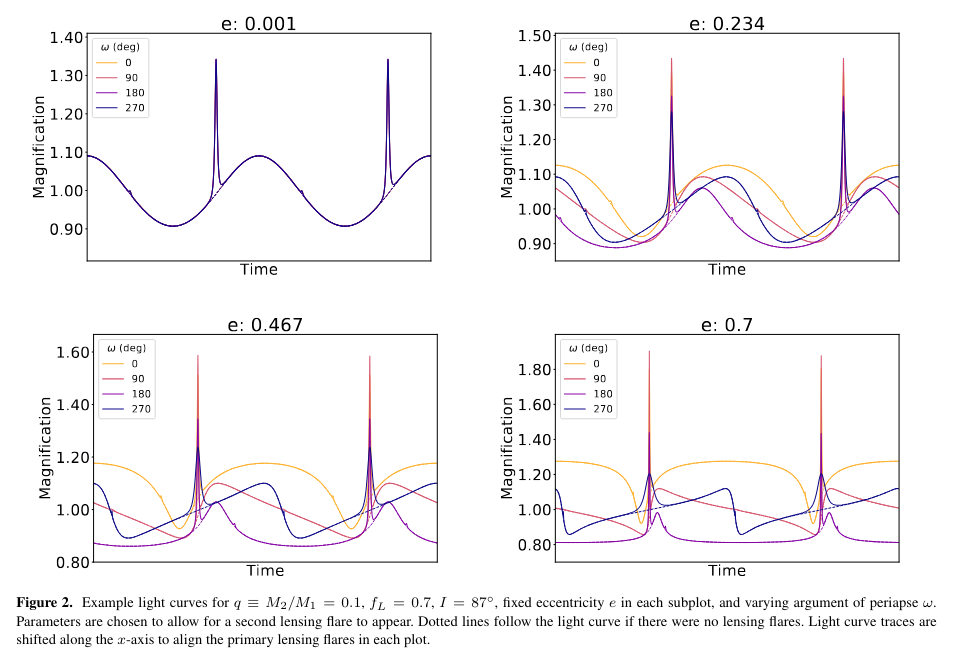

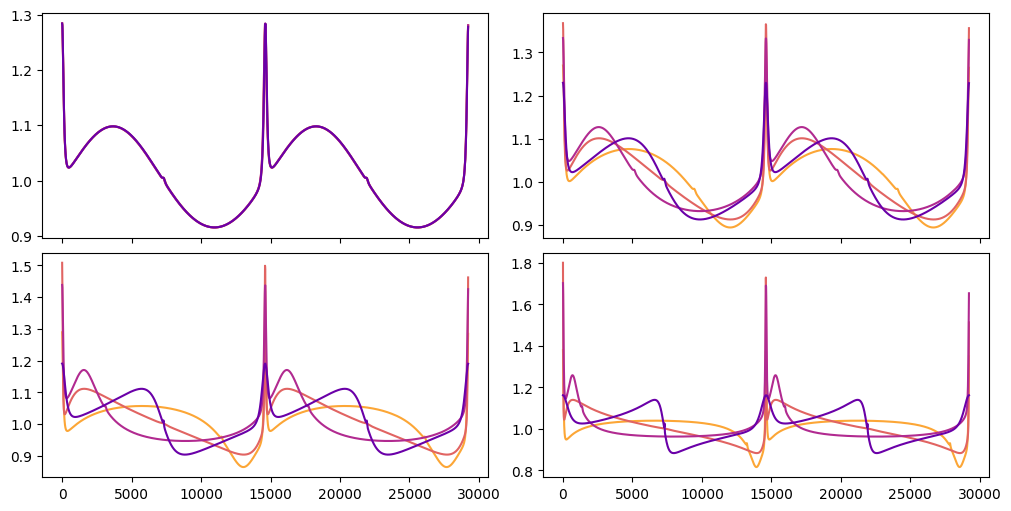

In [3]:
example_params = {
    'P': 20.0, 'L': 0.7, 'i': 87.0, 'logM1': jnp.log10(5) + 8, 'logM2': jnp.log10(5) + 7, # From paper
    'e': 0.001, 'w': 0.0, # to be changed per plot
    't0': 10.0, 'alpha': -2, 'vz': 0, 'z': 1.0, # Not specified in the paper
}

obs_P = _period_observed(example_params['P'], example_params['z'])
time = jnp.linspace(0, obs_P*2*365.25, 2000) # Twice observed period
fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=False, constrained_layout=True)

for ax, e in zip(axs.ravel(), [0.001, 0.234, 0.467, 0.7]):
    params = example_params.copy()
    params['e'] = e
    for w in [0, 90, 180, 270]:
        params['w'] = w
        flux = smbhb_nich(time, **params)[0]
        idx_max = np.argmax(flux)
        flux = np.roll(flux, -idx_max) # Align with maxima
        ax.plot(time, flux, label=w)
    ax.set_title(f'e:{e}')
    ax.legend()

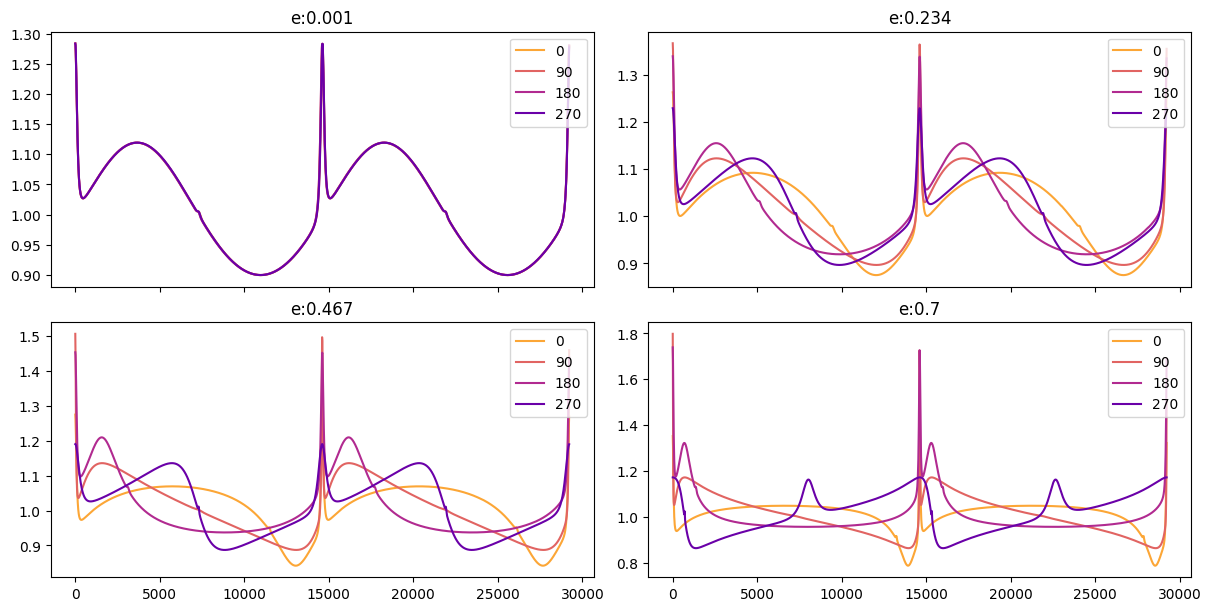

In [4]:
import numpy as np

# Platonium standard
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord



# Constants
G_CGS = c.G.cgs.value
C_CGS = c.c.cgs.value
M_SUN = c.M_sun.cgs.value
#YEAR  = ut.year()
YEAR  = 365.25*24*60*60
DAY   = 86400
RAD   = np.pi/180
floor = 1e-24


def _period_observed(P, z):
    """Orbital period in observers frame [s].
    """
    return P * (1 + z)



def _semimajor_axis(P, M):
    """Semi-major axis in binary rest frame [cm].
    """
    return (G_CGS * M * P**2 / (4 * np.pi**2))**(1/3)     



def _mean_anomaly(t, t0, T):
    """Determine the mean anomaly, fm [rad].

    Parameters
    ----------
    t : Time array
    T : Orbital period (observed)
    """
    return 2 * np.pi * (t - t0) / T


# @jit(cache=True, nopython=True, fastmath=True, parallel=False)
# def _eccentric_anomaly(fm, e):
#     """Determine the Eccentric anomaly, fe.

#     We here solve Kepler's equation (fm = fe – e sin fe) and use the
#     Newton-Raphson method to obtain the eccentric anomaly fe.
#     """
#     f = lambda fe: fe - e * np.sin(fe) - fm
#     fe = root_scalar(f, x0=fm, x1=fm + 0.1, method='secant').root
#     return fe



def _kepler_equation(E, e, M):
    """Represents Kepler's equation: M = E - e * sin(E)
    """
    return E - e * np.sin(E) - M


def _eccentric_anomaly(M, e, tolerance=1e-10):
    """Determine the Eccentric anomaly, E.

    We here solve Kepler's equation (M = E – e sin E) and use the
    Newton-Raphson method to obtain the eccentric anomaly E.
    """
    # Initial guess for E. A common starting point is M itself. For better performance,
    # a more sophisticated starting point can be used (e.g., Machin's).
    E = M
    # Iterate until the solution converges
    while True:
        f_E = _kepler_equation(E, e, M)
        f_prime_E = 1 - e * np.cos(E)
        # Newton-Raphson step
        E_next = E - f_E / f_prime_E
        # Check for convergence
        if abs(E_next - E) < tolerance:
            return E_next
        # Else save next step
        E = E_next


def _true_anomaly(fe, e):
    """Determine the true anomaly, f [rad].        
    """
    return 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(fe/2))


def _radial_vector(fe, e, a):
    """Radial vector of motion, r [cm].
    """        
    return a * (1 - e * np.cos(fe))


def _rv_semiamplitude(P, M1, M, q, a, i, e):
    """The RV semi-amplitude of secondary
    """
    K2 = (2 * np.pi / P) * (M1 / M) * a * np.sin(i) / np.sqrt(1 - e**2)
    K1 = q * K2
    return K1, K2


def _rv_vector(vz, K1, K2, f, e, w):
    """Projection of the velocity vector on to the line of sight.

    Equation from (Murray & Correria, 2010). Minus sign is introduced
    here as the RV is defined to be positive when object is moving away
    from the observed
    """
    vr1 = vz + K1 * (np.cos(w + f) + e * np.cos(w))
    vr2 = vz - K2 * (np.cos(w + f) + e * np.cos(w))    
    return vr1, vr2


def _xyz_orbital_plane(f, r1, a1, q, i, w, omega=np.pi/2):
    """Cartesian 3D position as function of time.
    """
    # Cartesian positions of primary and secondary 
    sini  = np.sin(i)
    cosi  = np.cos(i)
    sino  = np.sin(omega)
    coso  = np.cos(omega)
    sinwf = np.sin(w + f)
    coswf = np.cos(w + f)
    x1 = r1 * (coso * coswf - sino * sinwf * cosi)
    y1 = r1 * (sino * coswf + coso * sinwf * cosi)
    z1 = r1 * (sinwf * sini)
    x2 = -x1 / q
    y2 = -y1 / q
    z2 = -z1 / q
    return x1, y1, z1, x2, y2, z2

def _angular_separation_xy(x1, x2, y1, y2):
    """Angular separation between lens and source in cartesian coordinates, delta.
    """
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)


def _angular_einstein_radius(z1, z2, M1, M2, flip):
    """Einstein radius of primary and secondary [cm].
    """
    M_l = np.full(z1.shape, M1)
    D_l = -z1
    D_s = -z2
    M_l[flip] = M2
    D_l[flip] = -z2[flip]
    D_s[flip] = -z1[flip]
    D_rel = D_s - D_l
    #print(D_s - D_l)
    #D_rel = (1/D_l - 1/D_s)
    #print(D_rel)
    return np.sqrt(4 * G_CGS * M_l * D_rel) / C_CGS


def _magnification_point(u):
    """Magnification of point source limit.
    """
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

  
  
def smbhb_nich(time, z, t0, P, i, e, w, logM1, logM2, L, alpha, vz, **kwargs):

    # Make sure to work with floats (to avoid int overflow)
    z     = float(z)
    t0    = t0 * YEAR
    P     = P  * YEAR
    i     = np.deg2rad(i)
    e     = float(e)
    w     = np.deg2rad(w)
    M1    = 10**logM1 * M_SUN
    M2    = 10**logM2 * M_SUN
    L     = float(L)
    alpha = float(alpha)
    vz    = float(vz)
    # if tau is not None:
    #     tau = float(tau)
    # if sigma is not None:
    #     sigma = float(sigma)
    # if seed is not None:
    #     seed = int(seed) 

    # Total mass and mass fraction
    M = M1 + M2
    q = M2 / M1 

    # Orbital period in observers frame [s]
    T = _period_observed(P, z)

    # Check parameters
    fm = _mean_anomaly(time*DAY, t0, T)
    fe = np.array([_eccentric_anomaly(m, e) for m in fm])
    f  = _true_anomaly(fe, e)

    # Semi-major axis [cm]        
    a  = _semimajor_axis(P, M)
    a1 = a * M2 / M
    a2 = a * M1 / M
    #print(a, a1, a2)

    # Radial coordinate [cm]
    r  = _radial_vector(fe, e, a)
    r1 = _radial_vector(fe, e, a1)
    
    # RELATIVISTIC DOPPLER BOOSTING
    
    # The RV semi-amplitude of secondary [cm/s]
    K1, K2 = _rv_semiamplitude(P, M1, M, q, a, i, e)

    # Projection of the velocity vector on to the line of sight [cm/s]
    vr1, vr2 = _rv_vector(vz, K1, K2, f, e, w)

    # Gamma factors for each component [cm/s]
    arg = G_CGS * M * (2/r - 1/a) / C_CGS**2
    #v1_sqr = np.minimum(arg * (M2/M)**2, 1-floor)
    v1_sqr = arg * (M2/M) ** 2
    #v2_sqr = np.minimum(arg * (M1/M)**2, 1-floor)
    v2_sqr = arg * (M1/M) **2
    #print(v1_sqr, v2_sqr)
    gamma1 = 1 / np.sqrt(1 - v1_sqr)
    gamma2 = 1 / np.sqrt(1 - v2_sqr)
    #print(gamma1, gamma2)

    # Relativistic doppler boosting [pp1]
    D1 = 1 / (gamma1 * (1 - vr1/C_CGS))**(3 - alpha)
    D2 = 1 / (gamma2 * (1 - vr2/C_CGS))**(3 - alpha)
    D  = (1 - L) * D1 + L * D2
    
    # GRAVITATIONAL SELF-LENSING
    
    # Find cartesian position vectors
    x1, y1, z1, x2, y2, z2 = _xyz_orbital_plane(f, r1, a1, q, i, w)

    # Switch to select secondary as lens (or primary as source)
    flip = (z1 < 0)

    # Point-source magnification
    delta = _angular_separation_xy(x1, x2, y1, y2)
    theta = _angular_einstein_radius(z1, z2, M1, M2, flip)
    u     = delta / (theta + floor)
    M_ps  = _magnification_point(u)

    # COMBINE MODEL COMPONENTS

    x = flip
    flux    = (1 - L) * D1             + L * D2 * M_ps
    flux[x] = (1 - L) * D1[x]* M_ps[x] + L * D2[x]

    # Return: flux_total, flux_boost, flux_lens
    return flux, D, M_ps



example_params = {
    'P': 20.0, 'L': 0.7, 'i': 87.0, 'logM1': np.log10(5) + 8, 'logM2': np.log10(5) + 7, # From paper
    'e': 0.001, 'w': 0.0, # to be changed per plot
    't0': 10.0, 'alpha': -3, 'vz': 0, 'z': 1, # Not specified in the paper
}
obs_P = _period_observed(example_params['P'], example_params['z'])
time = np.linspace(0, obs_P*2*365.25, 2000) # Twice observed period
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=False, constrained_layout=True)

for ax, e in zip(axs.ravel(), [0.001, 0.234, 0.467, 0.7]):
    params = example_params.copy()
    params['e'] = e
    for w in [0, 90, 180, 270]:
        params['w'] = w #+ 180
        flux = smbhb_nich(time, **params)[0]
        idx_max = np.argmax(flux)
        flux = np.roll(flux, -idx_max) # Align with maxima
        ax.plot(time, flux, label=w)
    ax.set_title(f'e:{e}')
    ax.legend()